In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip -q install kagglehub

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset downloaded to:")
print(path)

100%|██████████| 2.29G/2.29G [00:27<00:00, 89.0MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [4]:
import os

for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")
    if len(files) > 0:
        print("Example:", files[:3])
    if root.count(os.sep) > 8:
        dirs[:] = []

/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2 -> 0 files
/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray -> 0 files


In [5]:
import os

# Find the train folder
train_dir = None
test_dir = None
val_dir = None

for root, dirs, files in os.walk(path):
    # Skip __MACOSX directories as they contain metadata files, not actual images
    if "__MACOSX" in root:
        continue

    folder_names = set(dirs)

    # Only assign if the directory hasn't been found yet to prioritize the first valid one
    if "train" in folder_names and train_dir is None:
        train_dir = os.path.join(root, "train")

    if "test" in folder_names and test_dir is None:
        test_dir = os.path.join(root, "test")

    if "val" in folder_names and val_dir is None:
        val_dir = os.path.join(root, "val")

    # Break early if all three directories have been found
    if train_dir and test_dir and val_dir:
        break

print("Train folder:", train_dir)
print("Test folder:", test_dir)
print("Validation folder:", val_dir)

Train folder: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train
Test folder: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/test
Validation folder: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/val


In [6]:
print("Classes in training data:")
print(os.listdir(train_dir))

print("\nClasses in test data:")
print(os.listdir(test_dir))

Classes in training data:
['NORMAL', 'PNEUMONIA']

Classes in test data:
['NORMAL', 'PNEUMONIA']


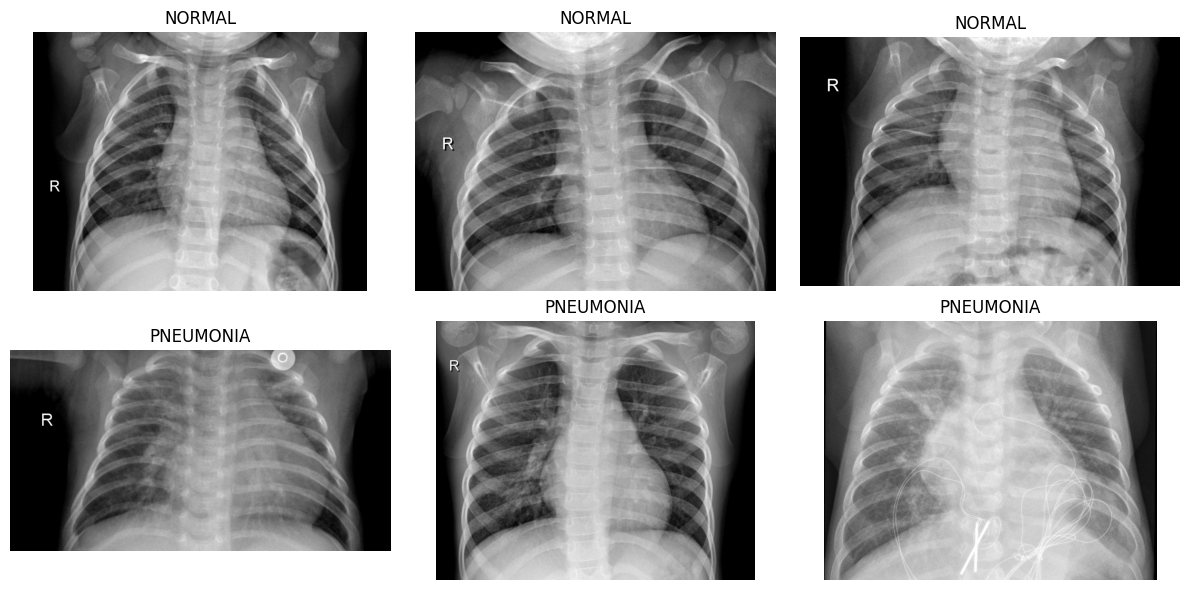

In [7]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Class folders
normal_dir = os.path.join(train_dir, "NORMAL")
pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")

# Get image paths
normal_images = [
    os.path.join(normal_dir, f)
    for f in os.listdir(normal_dir)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
][:3]

pneumonia_images = [
    os.path.join(pneumonia_dir, f)
    for f in os.listdir(pneumonia_dir)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
][:3]

# Display images
plt.figure(figsize=(12, 6))

for i, image_path in enumerate(normal_images):
    img = tf.keras.utils.load_img(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

for i, image_path in enumerate(pneumonia_images):
    img = tf.keras.utils.load_img(image_path)

    plt.subplot(2, 3, i + 4)
    plt.imshow(img, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes:", train_dataset.class_names)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


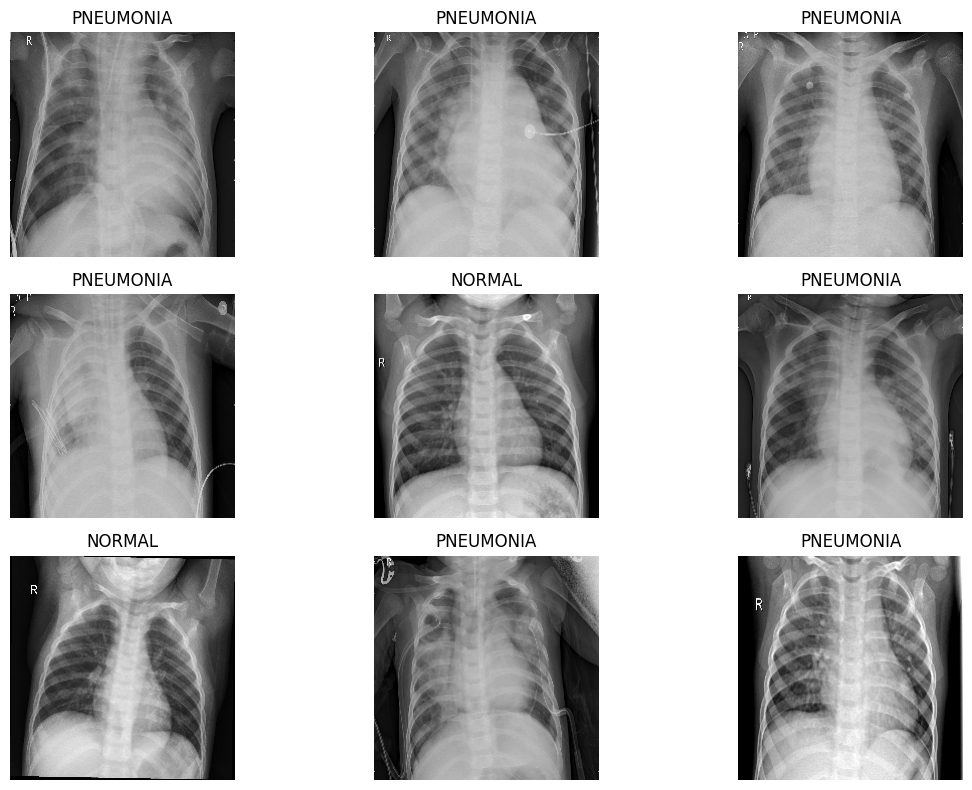

Batch shape: (32, 224, 224, 3)
Pixel range: 0.0 to 1.0


In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load one batch directly from the training dataset
for images, labels in train_dataset.take(1):

    # Normalize the batch
    images = images / 255.0

    # Display 9 images
    plt.figure(figsize=(12, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i])

        if labels[i].numpy() == 1:
            plt.title("PNEUMONIA")
        else:
            plt.title("NORMAL")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Display information
    print("Batch shape:", images.shape)
    print("Pixel range:",
          images.numpy().min(),
          "to",
          images.numpy().max())

In [11]:
import os
from PIL import Image

bad_files = []

for root, dirs, files in os.walk(train_dir):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            bad_files.append(file_path)

print("Number of invalid files:", len(bad_files))

for file in bad_files[:20]:
    print(file)

Number of invalid files: 0


In [12]:
import os

# Find the REAL train folder
train_candidates = []

for root, dirs, files in os.walk(path):
    # Ignore macOS metadata folders
    if "__MACOSX" in root:
        continue

    # We want a folder containing NORMAL and PNEUMONIA
    if os.path.basename(root) == "train":
        if os.path.isdir(os.path.join(root, "NORMAL")) and \
           os.path.isdir(os.path.join(root, "PNEUMONIA")):
            train_candidates.append(root)

print("Train folders found:")
for folder in train_candidates:
    print(folder)

Train folders found:
/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train
/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/chest_xray/train


In [13]:
train_dir = train_candidates[0]

# Find the correct test folder
test_candidates = []

for root, dirs, files in os.walk(path):
    if "__MACOSX" in root:
        continue

    if os.path.basename(root) == "test":
        if os.path.isdir(os.path.join(root, "NORMAL")) and \
           os.path.isdir(os.path.join(root, "PNEUMONIA")):
            test_candidates.append(root)

test_dir = test_candidates[0]

print("Correct training path:")
print(train_dir)

print("\nCorrect testing path:")
print(test_dir)

Correct training path:
/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train

Correct testing path:
/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/chest_xray/test


In [14]:
print("Training classes:")
print(os.listdir(train_dir))

print("\nTesting classes:")
print(os.listdir(test_dir))

Training classes:
['NORMAL', 'PNEUMONIA']

Testing classes:
['NORMAL', 'PNEUMONIA', '.DS_Store']


In [15]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes:", train_dataset.class_names)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


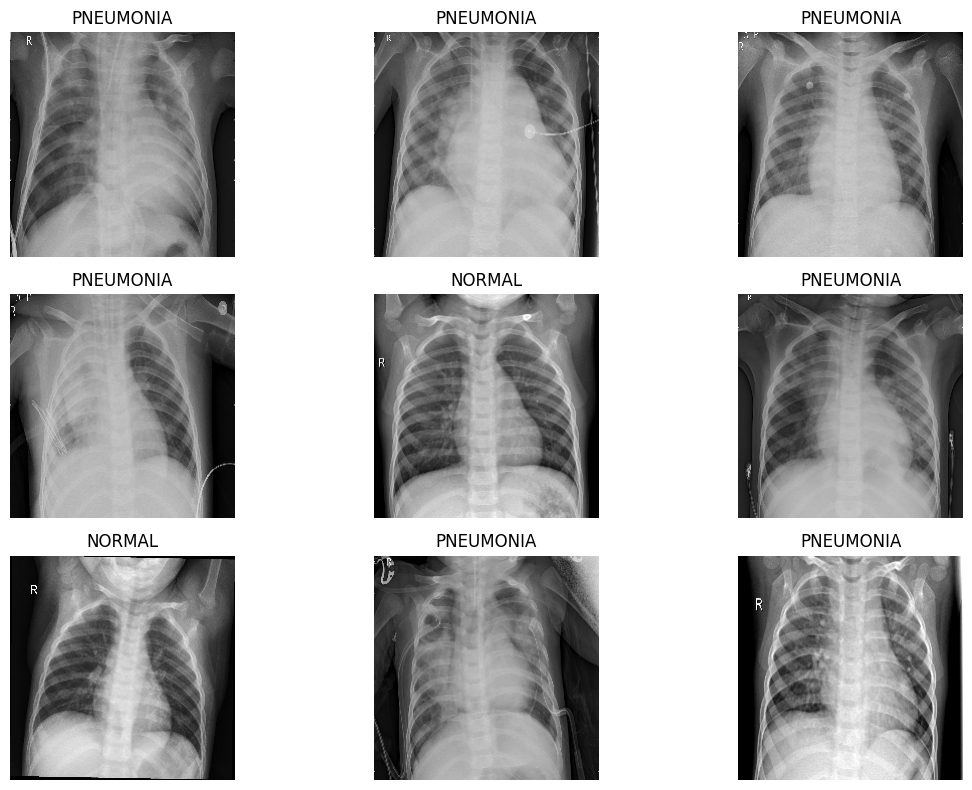

Batch shape: (32, 224, 224, 3)
Pixel range: 0.0 to 1.0


In [16]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    # Normalize
    images = images / 255.0

    plt.figure(figsize=(12, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())

        if labels[i].numpy() == 1:
            plt.title("PNEUMONIA")
        else:
            plt.title("NORMAL")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Batch shape:", images.shape)
    print("Pixel range:",
          images.numpy().min(),
          "to",
          images.numpy().max())

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    # Input image: 224 x 224 RGB
    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Binary output
    layers.Dense(1, activation="sigmoid")
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [19]:
history = cnn_model.fit(
    train_dataset.map(
        lambda x, y: (x / 255.0, y)
    ),
    validation_data=test_dataset.map(
        lambda x, y: (x / 255.0, y)
    ),
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 213ms/step - accuracy: 0.8831 - loss: 0.2918 - val_accuracy: 0.7532 - val_loss: 0.7311
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 201ms/step - accuracy: 0.9502 - loss: 0.1339 - val_accuracy: 0.7500 - val_loss: 0.9420
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 216ms/step - accuracy: 0.9597 - loss: 0.1049 - val_accuracy: 0.7869 - val_loss: 0.7794
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 208ms/step - accuracy: 0.9686 - loss: 0.0867 - val_accuracy: 0.7596 - val_loss: 1.0832
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 200ms/step - accuracy: 0.9743 - loss: 0.0681 - val_accuracy: 0.7500 - val_loss: 1.0577


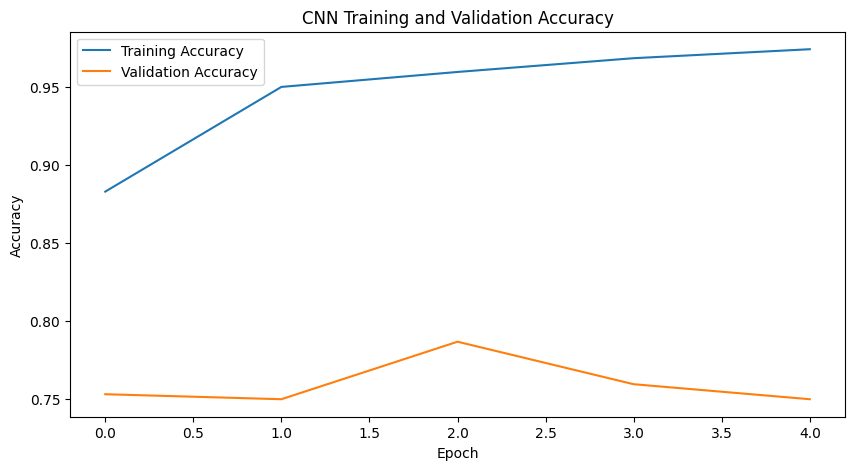

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

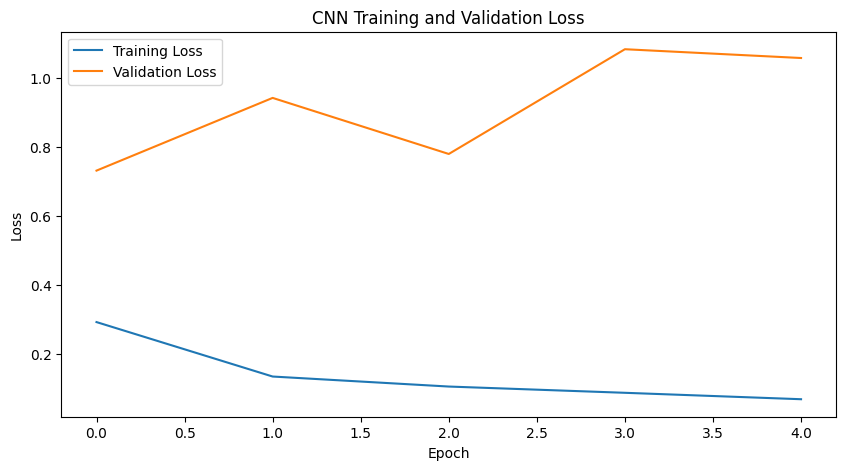

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [22]:
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset.map(lambda x, y: (x / 255.0, y))
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.7500 - loss: 1.0577
Test Loss: 1.0577330589294434
Test Accuracy: 0.75


In [23]:
cnn_model.save("chest_xray_cnn.keras")

print("Model saved successfully.")

Model saved successfully.


In [24]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


In [25]:
history = cnn_model.fit(
    train_dataset.map(lambda x, y: (x / 255.0, y)),
    validation_data=test_dataset.map(lambda x, y: (x / 255.0, y)),
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 203ms/step - accuracy: 0.9770 - loss: 0.0622 - val_accuracy: 0.7612 - val_loss: 1.0458
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 208ms/step - accuracy: 0.9824 - loss: 0.0522 - val_accuracy: 0.7452 - val_loss: 1.1886
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 200ms/step - accuracy: 0.9873 - loss: 0.0366 - val_accuracy: 0.7628 - val_loss: 1.5439
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 223ms/step - accuracy: 0.9870 - loss: 0.0354 - val_accuracy: 0.7404 - val_loss: 2.0245
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 208ms/step - accuracy: 0.9925 - loss: 0.0210 - val_accuracy: 0.7756 - val_loss: 1.5441


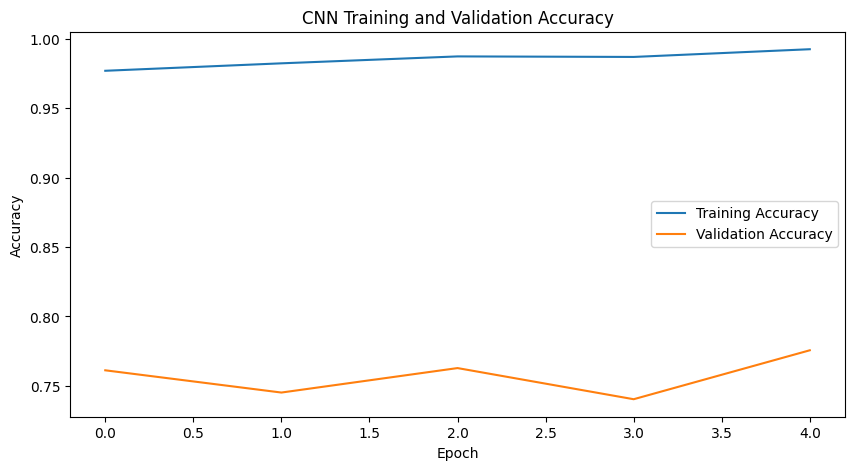

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

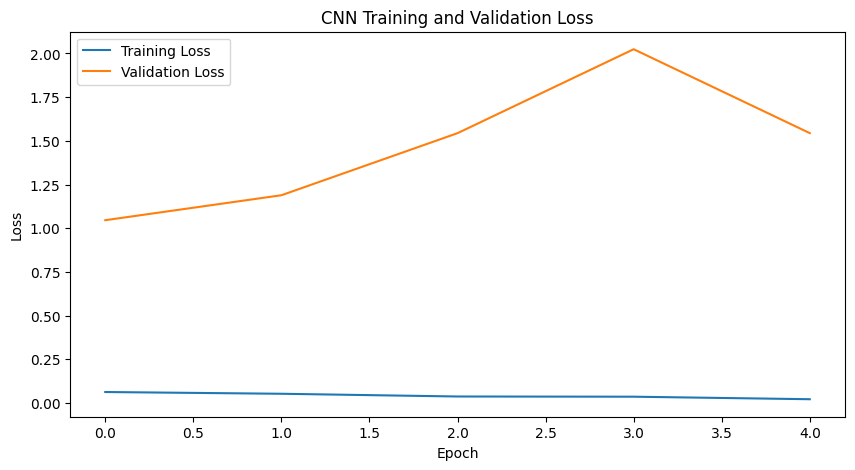

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [28]:
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset.map(lambda x, y: (x / 255.0, y))
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.7756 - loss: 1.5441
Test Loss: 1.5441237688064575
Test Accuracy: 0.7756410241127014


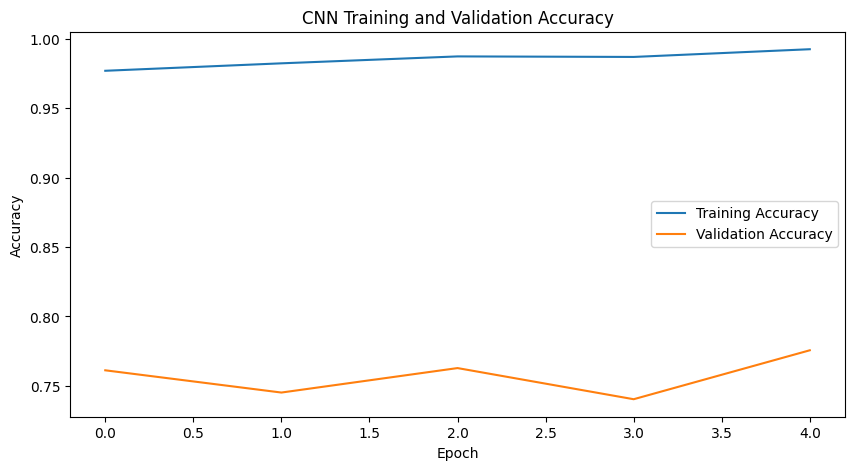

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

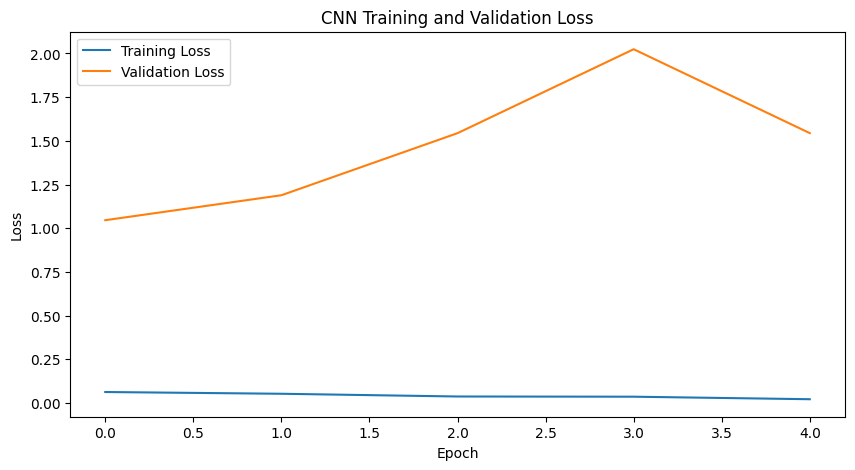

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [31]:
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset.map(lambda x, y: (x / 255.0, y))
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.7756 - loss: 1.5441
Test Loss: 1.5441237688064575
Test Accuracy: 0.7756410241127014


In [32]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels
y_true = []
y_pred_prob = []

for images, labels in test_dataset:
    images = images / 255.0

    predictions = cnn_model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(predictions.flatten())

# Convert probabilities to classes
y_pred = (np.array(y_pred_prob) >= 0.5).astype(int)
y_true = np.array(y_true).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.92      0.44      0.60       234
   PNEUMONIA       0.74      0.98      0.84       390

    accuracy                           0.78       624
   macro avg       0.83      0.71      0.72       624
weighted avg       0.81      0.78      0.75       624



In [33]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[103 131]
 [  9 381]]


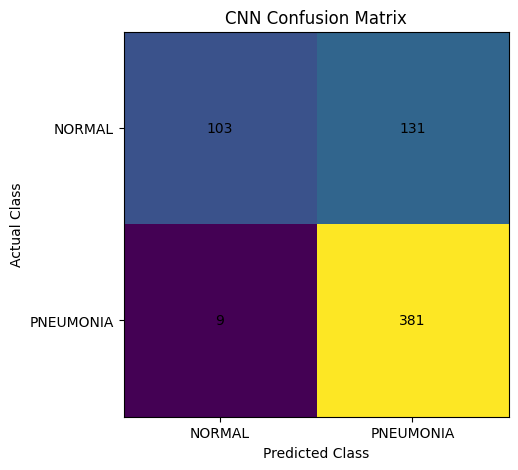

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [35]:
cnn_model.save("chest_xray_cnn.keras")

print("CNN model saved successfully.")

CNN model saved successfully.


/tmp/ipykernel_13984/2893491205.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_label = int(labels[0].numpy())


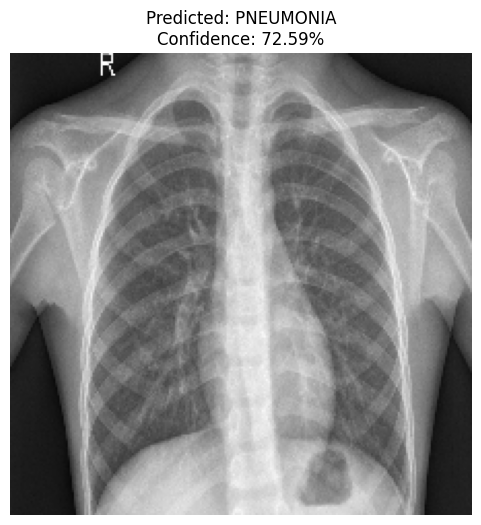

Actual: NORMAL
Predicted: PNEUMONIA
Confidence: 72.59%


In [36]:
for images, labels in test_dataset.take(1):
    sample_image = images[0]
    actual_label = int(labels[0].numpy())

    # Normalize
    input_image = sample_image / 255.0

    # Add batch dimension
    input_image = tf.expand_dims(input_image, axis=0)

    # Prediction
    prediction = cnn_model.predict(input_image, verbose=0)[0][0]

    if prediction >= 0.5:
        predicted_label = "PNEUMONIA"
        confidence = prediction
    else:
        predicted_label = "NORMAL"
        confidence = 1 - prediction

    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_label}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.show()

    print("Actual:",
          "PNEUMONIA" if actual_label == 1 else "NORMAL")

    print("Predicted:", predicted_label)
    print(f"Confidence: {confidence * 100:.2f}%")